## 3. Sklearn Random Forest Feature Importance

In [1]:
# Those are pretty confusing formulas so let’s demonstrate each step with the Iris Dataset.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

iris = load_iris()
data = iris["data"]
target = iris["target"]
#iris.keys()

In [2]:
iris["target"]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [3]:
data = pd.DataFrame(data, columns=iris["feature_names"])
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
# now we are not trying to answer which of the 3 species is this, but which one is 2 and 0,1
target = pd.Series(target).map({0:0, 1:0, 2:1})
target

0      0
1      0
2      0
3      0
4      0
      ..
145    1
146    1
147    1
148    1
149    1
Length: 150, dtype: int64

In [5]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators is the number of trees and for the sake of simplicity we set the
#  number of trees to 3 and limit the depth of trees in ensemble to be not greater than 3.
rfc = RandomForestClassifier(random_state=17, n_estimators=3, max_depth=3)
rfc.fit(data, target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [6]:
# After fitting, the list of all the trees is stored in estimators_ property.
tree_list = rfc.estimators_

[Text(0.4090909090909091, 0.875, 'node #0\nsepal length (cm) <= 5.75\ngini = 0.483\nsamples = 95\nvalue = [89, 61]\nclass = Y'),
 Text(0.18181818181818182, 0.625, 'node #1\npetal width (cm) <= 1.6\ngini = 0.061\nsamples = 44\nvalue = [61, 2]\nclass = Y'),
 Text(0.29545454545454547, 0.75, 'True  '),
 Text(0.09090909090909091, 0.375, 'node #2\ngini = 0.0\nsamples = 42\nvalue = [61, 0]\nclass = Y'),
 Text(0.2727272727272727, 0.375, 'node #3\ngini = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = N'),
 Text(0.6363636363636364, 0.625, 'node #4\npetal width (cm) <= 1.75\ngini = 0.437\nsamples = 51\nvalue = [28.0, 59.0]\nclass = N'),
 Text(0.5227272727272727, 0.75, '  False'),
 Text(0.45454545454545453, 0.375, 'node #5\npetal length (cm) <= 4.95\ngini = 0.225\nsamples = 20\nvalue = [27, 4]\nclass = Y'),
 Text(0.36363636363636365, 0.125, 'node #6\ngini = 0.0\nsamples = 16\nvalue = [26, 0]\nclass = Y'),
 Text(0.5454545454545454, 0.125, 'node #7\ngini = 0.32\nsamples = 4\nvalue = [1, 4]\nclass = N'),


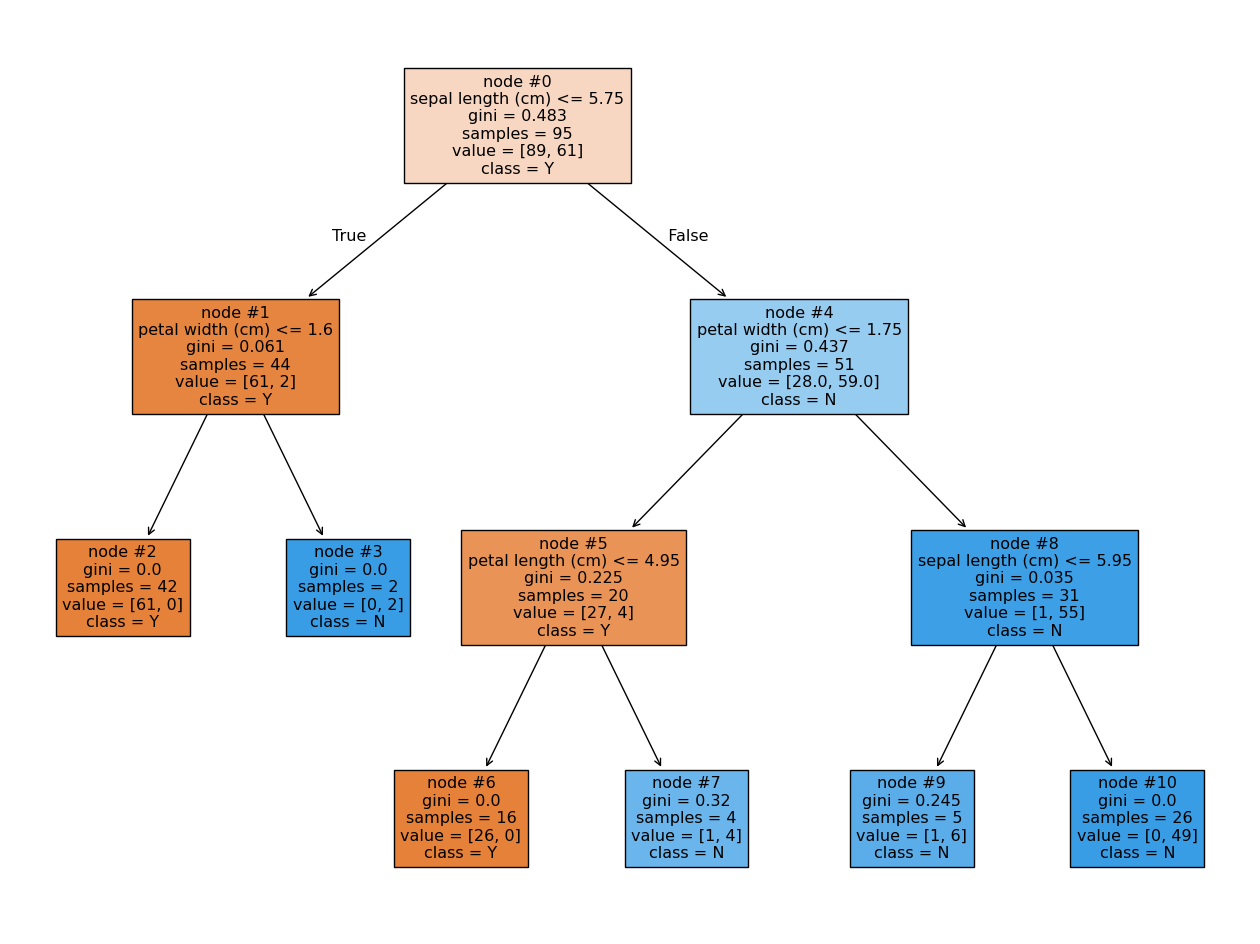

In [7]:
# visualizing the trees
from sklearn import tree

plt.figure(figsize=(16, 12))
tree.plot_tree(
    tree_list[0],
    filled=True,
    feature_names=iris["feature_names"],
    class_names=["Y", "N"],
    node_ids=True
)

[Text(0.5769230769230769, 0.875, 'node #0\npetal length (cm) <= 4.85\ngini = 0.457\nsamples = 99\nvalue = [97.0, 53.0]\nclass = Y'),
 Text(0.3076923076923077, 0.625, 'node #1\nsepal width (cm) <= 2.55\ngini = 0.06\nsamples = 63\nvalue = [94, 3]\nclass = Y'),
 Text(0.4423076923076923, 0.75, 'True  '),
 Text(0.15384615384615385, 0.375, 'node #2\npetal width (cm) <= 1.5\ngini = 0.198\nsamples = 9\nvalue = [16, 2]\nclass = Y'),
 Text(0.07692307692307693, 0.125, 'node #3\ngini = 0.0\nsamples = 8\nvalue = [16, 0]\nclass = Y'),
 Text(0.23076923076923078, 0.125, 'node #4\ngini = 0.0\nsamples = 1\nvalue = [0, 2]\nclass = N'),
 Text(0.46153846153846156, 0.375, 'node #5\npetal width (cm) <= 1.7\ngini = 0.025\nsamples = 54\nvalue = [78, 1]\nclass = Y'),
 Text(0.38461538461538464, 0.125, 'node #6\ngini = 0.0\nsamples = 52\nvalue = [77, 0]\nclass = Y'),
 Text(0.5384615384615384, 0.125, 'node #7\ngini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = Y'),
 Text(0.8461538461538461, 0.625, 'node #8\npetal wi

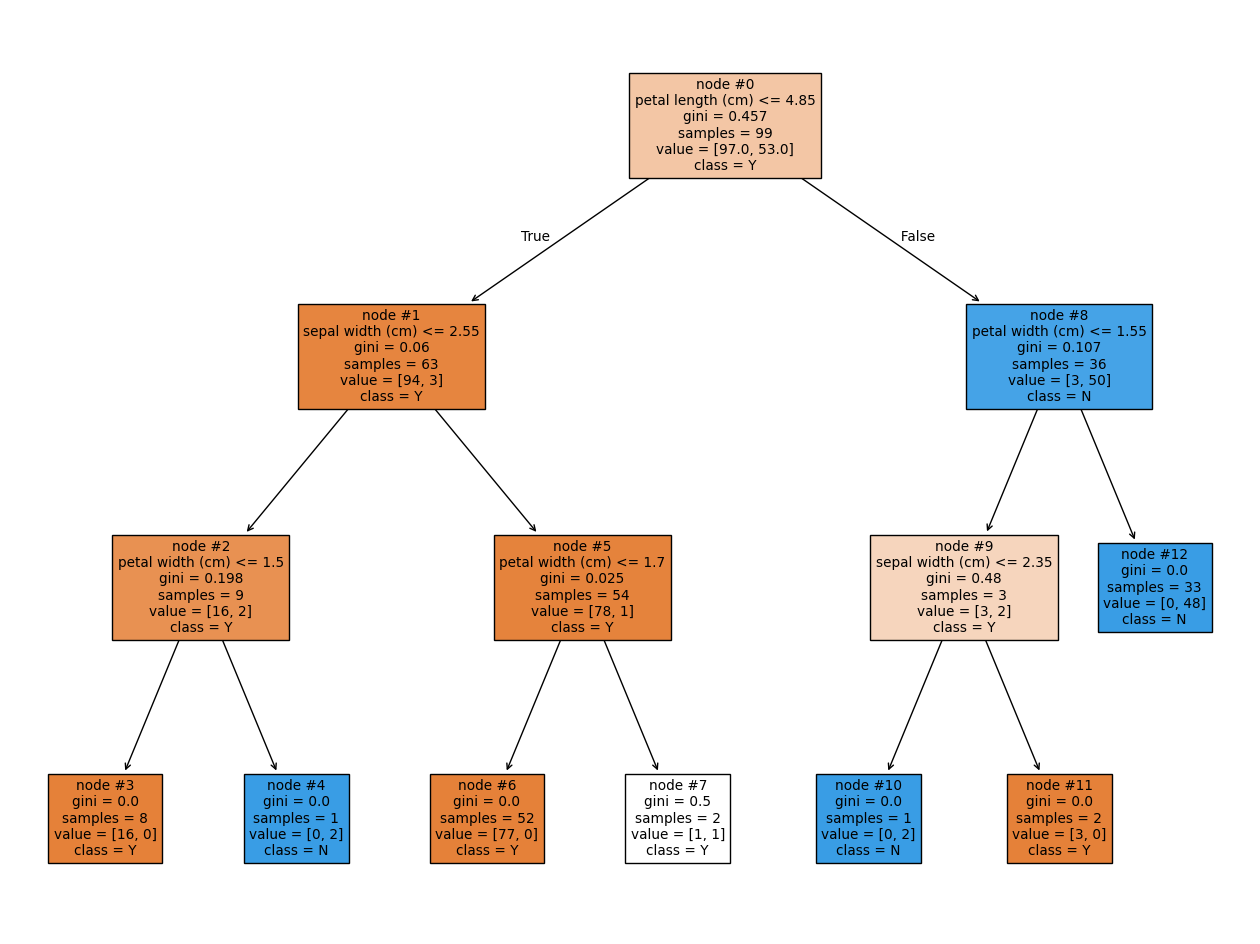

In [8]:
from sklearn import tree

plt.figure(figsize=(16, 12))
tree.plot_tree(
    tree_list[1],
    filled=True,
    feature_names=iris["feature_names"],
    class_names=["Y", "N"],
    node_ids=True
)

[Text(0.6, 0.8333333333333334, 'node #0\npetal width (cm) <= 1.65\ngini = 0.464\nsamples = 104\nvalue = [95.0, 55.0]\nclass = Y'),
 Text(0.4, 0.5, 'node #1\npetal length (cm) <= 4.95\ngini = 0.112\nsamples = 70\nvalue = [95, 6]\nclass = Y'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'node #2\ngini = 0.0\nsamples = 66\nvalue = [95, 0]\nclass = Y'),
 Text(0.6, 0.16666666666666666, 'node #3\ngini = 0.0\nsamples = 4\nvalue = [0, 6]\nclass = N'),
 Text(0.8, 0.5, 'node #4\ngini = 0.0\nsamples = 34\nvalue = [0, 49]\nclass = N'),
 Text(0.7, 0.6666666666666667, '  False')]

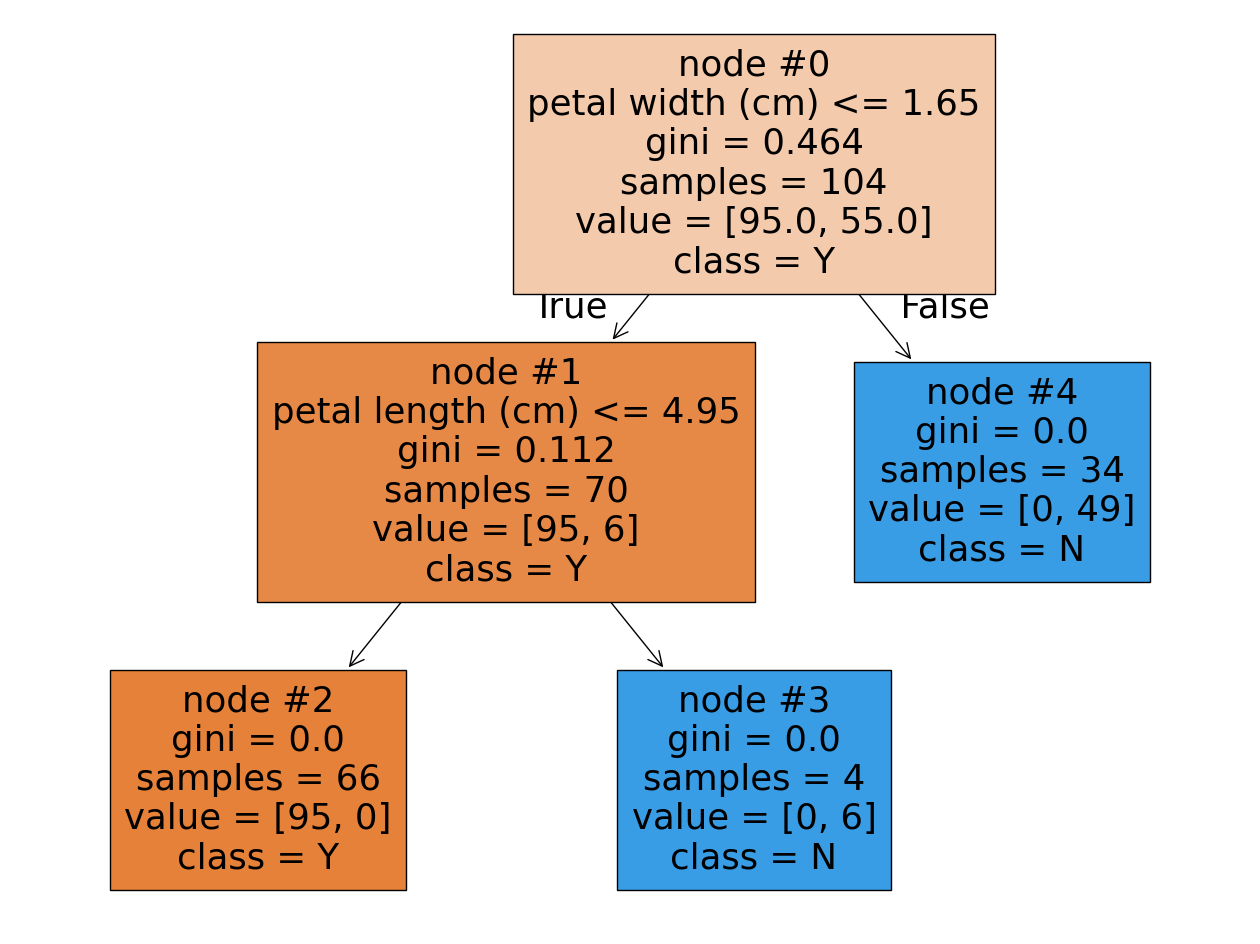

In [9]:
from sklearn import tree

plt.figure(figsize=(16, 12))
tree.plot_tree(
    tree_list[2],
    filled=True,
    feature_names=iris["feature_names"],
    class_names=["Y", "N"],
    node_ids=True
)

In [10]:
print(iris["feature_names"])
print(rfc.feature_importances_)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[0.14857187 0.01324612 0.36155096 0.47663104]


# 4. Practical example

Let’s consider the results of a survey given to visitors of hostels listed on Booking.com and TripAdvisor.com. Our features here are the average ratings for different categories including service quality, room condition, value for money, etc. Our target variable is the hostel’s overall rating on the website.

In [11]:
from sklearn.ensemble import RandomForestRegressor

In [12]:
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

Feature Ranking
1. Staff 0.210751
2. Value for money 0.175066
3. Customer Co-creation 0.122167
4. Shared space condition 0.112113
5. Extra services 0.081404
6. General conditions & conveniences 0.074633
7. Check-in and check-out 0.072012
8. Hostel booking 0.059564
9. Shared kitchen condition 0.053865
10. Room condition 0.038425


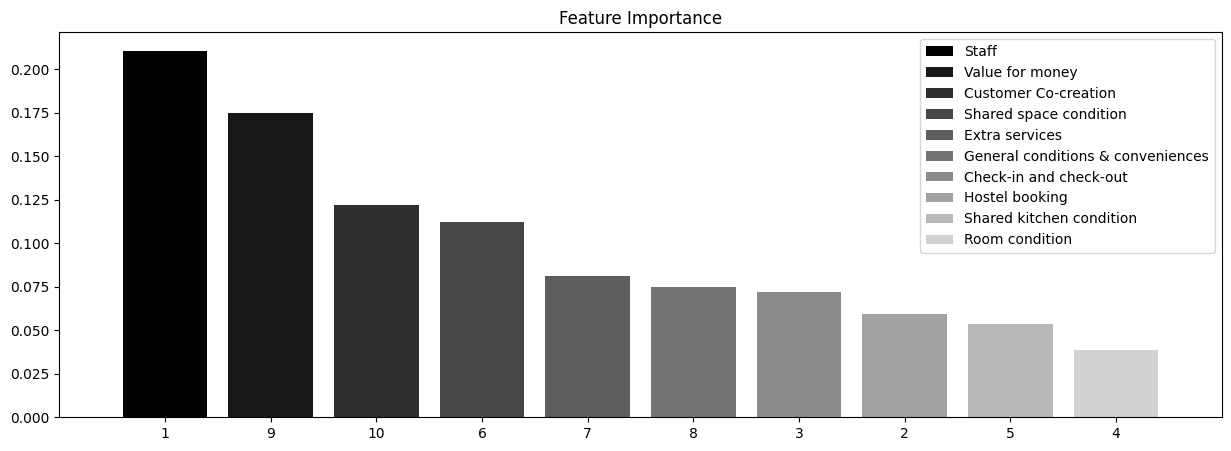

In [15]:
hostel_data = pd.read_csv(DATA_PATH + "hostel_factors.csv")
features = {
    "f1": u"Staff",
    "f2": u"Hostel booking",
    "f3": u"Check-in and check-out",
    "f4": u"Room condition",
    "f5": u"Shared kitchen condition",
    "f6": u"Shared space condition",
    "f7": u"Extra services",
    "f8": u"General conditions & conveniences",
    "f9": u"Value for money",
    "f10": u"Customer Co-creation",
}

forest = RandomForestRegressor(n_estimators=100, random_state=0, max_features=10)

forest.fit(hostel_data.drop(["hostel", "rating"], axis=1), hostel_data["rating"])
importances = forest.feature_importances_

#importances, np.argsort(importances)
""" (array([0.21075115, 0.05956397, 0.07201179, 0.03842547, 0.0538654 ,
            0.11211331, 0.08140372, 0.07463296, 0.17506567, 0.12216654]),
    array([3, 4, 1, 2, 7, 6, 5, 9, 8, 0])) """

indices = np.argsort(importances)[::-1] # -> array([0, 8, 9, 5, 6, 7, 2, 1, 4, 3])
# indices = np.argsort(-importances) -> same effect

# plot the feature importance of the forest
num_to_plot = 10
feature_indices = [ind + 1 for ind in indices[:num_to_plot]]

# Print the feature ranking
print("Feature Ranking")

for f in range(num_to_plot):
    print(
        "%d. %s %f"
        % (f + 1, features["f" + str(feature_indices[f])], importances[indices[f]])
    )

plt.figure(figsize=(15,5))
plt.title(u"Feature Importance")
bars = plt.bar(
    range(num_to_plot),
    importances[indices[:num_to_plot]],
    color=([str(i / float(num_to_plot + 1)) for i in range(num_to_plot)]),
    align="center",
)
ticks = plt.xticks(range(num_to_plot), feature_indices)
plt.xlim([-1, num_to_plot])
plt.legend(bars, [u"".join(features["f" + str(i)]) for i in feature_indices])
